# Исследование — Анализ рынка автомобилей: предсказание стоимости автомобилей с пробегом

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

**Цель исследования:**

Целью данного проекта является создание и внедрение моделей машинного обучения, которые помогут оценить рыночную стоимость автомобилей с пробегом. Это позволит компании более точно устанавливать цены на автомобили, улучшая тем самым конкурентоспособность и удовлетворенность клиентов.

**Описание исходных данных для анализа:**

Компания предоставила следующие данные о характеристиках автомобилей, включающие информацию о пробеге, мощности, типе кузова и других параметрах. Целевым признаком является цена автомобиля в евро.

[autos.csv](https://code.s3.yandex.net/datasets/autos.csv)


- `DateCrawled` — дата скачивания анкеты из базы;
- `VehicleType` — тип автомобильного кузова;
- `RegistrationYear` — год регистрации автомобиля;
- `Gearbox` — тип коробки передач;
- `Power` — мощность (л. с.);
- `Model` — модель автомобиля;
- `Kilometer` — пробег (км);
- `RegistrationMonth` — месяц регистрации автомобиля;
- `FuelType` — тип топлива;
- `Brand` — марка автомобиля;
- `NotRepaired` — была ли машина в ремонте;
- `DateCreated` — дата создания анкеты;
- `NumberOfPictures` — количество фотографий автомобиля;
- `PostalCode` — почтовый индекс владельца анкеты;
- `LastSeen` — дата последней активности пользователя;
- `Price` — цена (евро, **целевой признак**).

Данные должны быть загружены и подготовлены для последующего анализа и моделирования. Выбор моделей включает как более простые алгоритмы, так и методы градиентного бустинга, такие как LightGBM, с акцентом на качество предсказаний и время выполнения.

## Настройка рабочей среды

### Установка и импорт библиотек

In [1]:
# Установка библиотек
!pip install phik -q
!pip install lightgbm -q
!pip install catboost -q

In [2]:
!pip install scikit-learn -q
!pip install --upgrade scikit-learn -q

In [3]:
# Импорт библиотек
import pandas as pd
import os
import re
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler
)

from sklearn.metrics import root_mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from time import time

from sklearn.dummy import DummyRegressor

In [4]:
# Константы
RANDOM_STATE = 42

### Объявление функций

In [5]:
def load_csv(file_path, file_url=None, date_columns=None):
    """
    Загружает данные из локального CSV файла или по URL.

    Функция проверяет, существует ли файл по указанному пути. 
    Если файл существует, данные загружаются из него. 
    В противном случае данные загружаются по указанному URL, если он предоставлен.

    Параметры:
    file_path (str): Путь к локальному файлу CSV.
    file_url (str, optional): URL для загрузки данных, если файл не найден.
    date_columns (list, optional): Список имен столбцов для преобразования в даты.

    Возвращает:
    DataFrame или None: Загруженные данные в формате DataFrame, или None в случае ошибки.
    """
    try:
        # Проверяем, существует ли файл по указанному пути
        if os.path.exists(file_path):
            return pd.read_csv(file_path, parse_dates=date_columns)
        elif file_url:
            # Загружаем данные из URL, если файл не найден
            return pd.read_csv(file_url, parse_dates=date_columns)
        else:
            print("File not found and no URL provided.")
            return None
    except Exception as e:
        # В случае ошибки выводим сообщение
        print("Something went wrong:", e)
        return None

In [6]:
# Создаем функцию для вывода общей информации о датасете
def df_info(data):
    """
    Эта функция выводит общую информацию о переданном датасете, включая:
    1. Первые 5 строк для предварительного просмотра.
    2. Общую информацию о типах данных и количестве ненулевых значений.
    3. Статистику по колонкам, включая описательные статистики.
    4. Долю пропусков в каждом столбце.
    5. Количество полных дубликатов в датасете.
    
    Параметры:
    data : pd.DataFrame
        Датасет, для которого нужно вывести информацию.
    """
    
    # 1. Выводим первые 5 строк датасета для предварительного просмотра
    print(f'1. Первые 5 строк датасета:')
    display(data.head())
          
    # 2. Выводим общую информацию о датасете
    print('\n2. Общая информация о датасете:')
    print(data.info())
    
    # 3. Выводим статистику по колонкам
    print('\n3. Статистика по колонкам:')
    display(data.describe(include='all', datetime_is_numeric=True))
    
    # 4. Вычисляем и отображаем долю пропусков в колонках
    print('\n4. Доля пропусков в колонках:')
    missing_data = pd.DataFrame(round(data.isna().mean() * 100, 4).sort_values())
    display(missing_data.style.background_gradient('coolwarm'))
    
    # 5. Подсчитываем и выводим количество полных дубликатов
    print('\n5. Количество полных дубликатов:', data.duplicated().sum())

In [7]:
def plot_box_features_target(data, features, target, top_n=None):
    """
    Построение ящиков с усами для заданных признаков и целевой переменной.

    :param data: DataFrame с данными
    :param features: Список столбцов-признаков для группировки
    :param target: Целевой столбец
    :param top_n: Количество значений для отображения в топе (по умолчанию None - все значения)
    """
    n_cols = 2
    n_rows = (len(features) + n_cols - 1) // n_cols  # Вычисляем количество рядов

    plt.figure(figsize=(15, 5 * n_rows))  # Устанавливаем общий размер графиков

    for i, column in enumerate(features):
        # Получаем топ-n значений по частоте
        if top_n is not None:
            top_values = data[column].value_counts().nlargest(top_n).index
        else:
            top_values = data[column].unique()  # Получаем все уникальные значения

        # Фильтруем данные для визуализации только по выбранным значениям
        filtered_data = data[data[column].isin(top_values)]

        plt.subplot(n_rows, n_cols, i + 1)  # Создаем подграфик
        sns.boxplot(data=filtered_data, x=column, y=target)
        plt.title(f'Ящик с усами: Уровень {target} по {column}')
        plt.xlabel(column)  # Подпись оси X
        plt.ylabel(target)  # Подпись оси Y
        plt.xticks(rotation=45)  # Поворачиваем подписи по оси X, если нужно

    plt.tight_layout()  # Настраиваем отступы
    plt.show()

In [8]:
# Функция для нахождения границы диаграммы размаха (границы выбросов)
def wiskers(df, columns):
    result = []

    if isinstance(columns, str):
        columns = [columns]

    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_whisker = df[column][df[column] >= (Q1 - 1.5 * IQR)].min()
        upper_whisker = df[column][df[column] <= (Q3 + 1.5 * IQR)].max()

        result.append((lower_whisker, upper_whisker))

    return result

In [9]:
def plot_scatter_line_chart(data, y_label='Значение признака Y', title=None, hue=None, palette=None):
    """
    Функция для построения точечных и линейных графиков для числовых столбцов DataFrame.
    
    Параметры:
    - data: DataFrame или Series, содержащий данные для визуализации.
    - y_label: str, имя столбца, который будет отображаться по оси Y (по умолчанию 'Значение признака Y').
    - title: str, заголовок для графиков (не используется, можно дополнить).
    - hue: str, имя столбца для цветового кодирования точек и линий (по умолчанию None).
    - palette: str или список, цветовая палитра для графиков (по умолчанию None).
    
    Исключения:
    - ValueError: если указанный столбец hue не существует в DataFrame.
    """
    
    # Если данные представлены в виде Series, преобразуем в DataFrame
    if isinstance(data, pd.Series):
        data = pd.DataFrame(data)

    # Проверка, существует ли hue в столбцах
    if hue and hue not in data.columns:
        raise ValueError(f"Столбец для hue '{hue}' не существует в DataFrame.")

    # Выбор числовых столбцов для построения графиков
    numerical_cols = data.select_dtypes(include=['number']).columns

    # Удаление y_label из списка числовых столбцов, если он там есть
    if y_label in numerical_cols:
        numerical_cols = numerical_cols[numerical_cols != y_label]

    num_plots = len(numerical_cols)

    # Проверка наличия числовых столбцов для построения графиков
    if num_plots == 0:
        print("Нет числовых столбцов для построения графиков.")
        return

    # Создание подграфиков для каждого числового столбца
    fig, axes = plt.subplots(num_plots, 2, figsize=(12, 3 * num_plots))

    for i, col in enumerate(numerical_cols):
        # Построение точечного графика
        sns.scatterplot(data=data, x=col, y=y_label, ax=axes[i][0], palette=palette, hue=hue)
        axes[i][0].set_xlabel(col)
        axes[i][0].set_ylabel(y_label)
        axes[i][0].set_title(f'Точечный график: {col} vs {y_label}')

        # Построение линейного графика
        sns.lineplot(data=data, x=col, y=y_label, ax=axes[i][1], palette=palette, hue=hue)
        axes[i][1].set_xlabel(col)
        axes[i][1].set_ylabel(y_label)
        axes[i][1].set_title(f'Линейный график: {col} vs {y_label}')

    # Настройка отображения графиков
    plt.tight_layout()
    plt.show()

In [10]:
def find_best_model_grid(pipe, param_grid, X_train, y_train, scoring, cv=3, n_jobs=-1):
    """
    Поиск лучшей модели с использованием GridSearch для оптимизации гиперпараметров.
    
    Параметры:
    pipe : sklearn.pipeline.Pipeline
        Пайплайн модели для обучения.
    param_grid : dict
        Словарь с гиперпараметрами для поиска.
    n_jobs : int, optional
        Количество потоков для параллельного выполнения (-1 для использования всех доступных).
    
    Возвращает:
        Объект GridSearch с обученной моделью и DataFrame с результатами.
    """
    
    # 1. Инициализация GridSearchCV
    grid_search = GridSearchCV(
        pipe,
        param_grid,
        cv=cv,  # 3-кратная перекрестная проверка по умолчанию
        scoring=scoring, 
        n_jobs=n_jobs  # Параллельное выполнение
    )

    # 2. Обучение модели на тренировочных данных
    grid_search.fit(X_train, y_train)

    # 3. Вывод информации о лучшей модели и её параметрах
    print('Лучшая модель и её параметры')
    
    if cv is not None:
        print('Лучшая метрика на кросс-валидации для лучшей модели:', abs(grid_search.best_score_))  # Лучшая метрика на обучении  
    else: 
        print('Лучшая метрика для лучшей модели:', abs(grid_search.best_score_))  # Лучшая метрика на обучении     
    
    display(grid_search.best_estimator_)  # Отображение лучшего оценивателя
              
    # 4. Сохранение результатов в DataFrame
    results = pd.DataFrame(grid_search.cv_results_)  # Сохранение результатов в таблицу
  
    
    # 5. Возврат объекта GridSearch и DataFrame с результатами
    return grid_search, results

In [11]:
def plot_box_hist_chart(data, plot_type='both', x_label='Значение признака', y_label='Частота', title=None, hue=None, palette=None, bins='auto'):
    """
    Функция для отображения диаграмм размаха и гистограмм для числовых столбцов в DataFrame.

    Параметры:
    - data: DataFrame или Series, данные для визуализации
    - plot_type: str, определяет тип графиков: 'boxplot', 'histplot' или 'both' (по умолчанию 'both')
    - x_label: str, подпись оси X (по умолчанию 'Значение признака')
    - y_label: str, подпись оси Y (по умолчанию 'Частота')
    - title: str, заголовок графика (по умолчанию None)
    - hue: str, имя столбца для цветового кодирования гистограммы (по умолчанию None)
    - palette: str, цветовая палитра для графиков (по умолчанию None)
    - bins: int, количество столбцов в гистограмме (по умолчанию 'auto')

    Возвращает:
    - Выводит диаграммы размаха и гистограмм на основе переданных данных.
    """

    # Проверка, являются ли данные объектом Series, и приведение к DataFrame при необходимости
    if isinstance(data, pd.Series):
        data = pd.DataFrame(data)

    # Выбор числовых столбцов из данных
    numerical_cols = data.select_dtypes(include=['number']).columns
    num_plots = len(numerical_cols)

    # Создание подходящего количества подграфиков в зависимости от числа числовых столбцов
    if num_plots == 1:
        fig, axes = plt.subplots(1, 2, figsize=(12, 3))
        axes = [axes]
    else:
        fig, axes = plt.subplots(num_plots, 2, figsize=(12, 3 * num_plots))

    # Построение графиков для каждого числового столбца
    for i, col in enumerate(numerical_cols):
        # Диаграмма размаха
        if plot_type == 'boxplot' or plot_type == 'both':
            sns.boxplot(x=data[col], ax=axes[i][0], palette=palette)
            axes[i][0].set_xlabel(x_label)
            axes[i][0].set_title(f'Диаграмма размаха по колонке: {col}')

        # Гистограмма
        if plot_type == 'histplot' or plot_type == 'both':
            if hue is not None:
                sns.histplot(x=data[col], bins=bins, palette=palette, kde=True, ax=axes[i][1], hue=data[hue])
            else:
                sns.histplot(x=data[col], bins=bins, palette=palette, kde=True, ax=axes[i][1])
            axes[i][1].set_xlabel(x_label)
            axes[i][1].set_ylabel(y_label)
            axes[i][1].set_title(f'Распределение значений в колонке: {col}')

            # Добавление линий для mean, median и mode
            mean_val = data[col].mean()
            median_val = data[col].median()
            mode_val = data[col].mode()[0]  # Берем первую моду

            axes[i][1].axvline(mean_val, color='red', linestyle='--', label='Среднее')
            axes[i][1].axvline(median_val, color='blue', linestyle='--', label='Медиана')
            axes[i][1].axvline(mode_val, color='green', linestyle='--', label='Мода')

            # Добавление легенды при наличии hue
            if hue is not None:
                axes[i][1].legend(title=hue)

    # Улучшение компоновки графиков и вывод
    plt.tight_layout()
    plt.show()

In [12]:
def find_best_model(pipe, param_grid, X_train, y_train, scoring, search_type='grid', cv=3, n_jobs=-1, n_iter=10):
    """
    Поиск лучшей модели с использованием GridSearch или RandomizedSearch для оптимизации гиперпараметров.
    
    Параметры:
    pipe : sklearn.pipeline.Pipeline
        Пайплайн модели для обучения.
    param_grid : dict
        Словарь гиперпараметров для поиска.
    X_train : array-like, shape (n_samples, n_features)
        Обучающие данные.
    y_train : array-like, shape (n_samples,)
        Обучающие метки.
    scoring : str или callable
        Метрика для оценки модели.
    search_type : str, optional
        Тип поиска ('grid' для GridSearchCV, 'random' для RandomizedSearchCV).
    cv : int, optional
        Количество складок для кросс-валидации (по умолчанию 3).
    n_jobs : int, optional
        Количество потоков для параллельного выполнения (-1 для использования всех доступных).
    n_iter : int, optional
        Количество итераций для RandomizedSearchCV (по умолчанию 100).

    Возвращает:
        tuple:
            - gs : GridSearchCV или RandomizedSearchCV
                Объект с обученной моделью.
            - results : pd.DataFrame
                DataFrame с результатами кросс-валидации.
            - time_fit : float
                Время, затраченное на обучение лучшей модели.
            - time_pred : float
                Время, затраченное на предсказание лучшей модели.
    """
    
    # 1. Инициализация GridSearchCV или RandomizedSearchCV
    if search_type == 'grid':
        search = GridSearchCV(
            pipe,
            param_grid,
            cv=cv,
            scoring=scoring,
            n_jobs=n_jobs
        )
    elif search_type == 'random':
        search = RandomizedSearchCV(
            pipe,
            param_distributions=param_grid,
            n_iter=n_iter,
            cv=cv,
            scoring=scoring,
            n_jobs=n_jobs
        )
    else:
        raise ValueError("search_type должен быть 'grid' или 'random'.")

    # 2. Обучение модели на тренировочных данных и замер времени
    start_grid = time()
    search.fit(X_train, y_train)
    end_grid = time()
    time_gs = end_grid - start_grid

    # 3. Сохранение результатов поиска  
    model = search.best_estimator_
    score = abs(search.best_score_)
    results = pd.DataFrame(search.cv_results_)

    # 4. Замер времени обучения лучшей модели на обучающих данных
    start_fit = time()
    model.fit(X_train, y_train)
    end_fit = time()
    time_fit = end_fit - start_fit

    # 5. Замер времени предсказания лучшей модели на обучающих данных
    start_pred = time()
    predictions = model.predict(X_train)
    end_pred = time()
    time_pred = end_pred - start_pred
    
    # 6. Вывод информации о лучшей модели и её параметрах
    print('Лучшая модель и её параметры:')
    display(model)
    
    # 7. Вывод лучшей метрики на кросс-валидации
    print('Лучшая метрика на кросс-валидации для лучшей модели:', score)

    # 8. Печать времени выполнения
    print()
    print(f'Время поиска лучшей модели: {time_gs:.4f} секунд')
    print(f'Время обучения лучшей модели: {time_fit:.4f} секунд')
    print(f'Время предсказания лучшей модели на обучающей выборке: {time_pred:.4f} секунд')

    # 9. Возврат объекта поиска, DataFrame с результатами и времени
    return search, results, score, time_fit, time_pred

## Подготовка данных

In [13]:
autos_path = '/datasets/autos.csv'
autos_url = 'https://code.s3.yandex.net/datasets/autos.csv'

autos = load_csv(autos_path, autos_url, date_columns=['DateCrawled', 'DateCreated', 'LastSeen'])

In [14]:
# Общая информация о train_job_satisfaction_rate
df_info(autos)

1. Первые 5 строк датасета:


,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31,0,60437,2016-04-06 10:17:21



2. Общая информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   DateCrawled        354369 non-null  datetime64[ns]
 1   Price              354369 non-null  int64         
 2   VehicleType        316879 non-null  object        
 3   RegistrationYear   354369 non-null  int64         
 4   Gearbox            334536 non-null  object        
 5   Power              354369 non-null  int64         
 6   Model              334664 non-null  object        
 7   Kilometer          354369 non-null  int64         
 8   RegistrationMonth  354369 non-null  int64         
 9   FuelType           321474 non-null  object        
 10  Brand              354369 non-null  object        
 11  Repaired           283215 non-null  object        
 12  DateCreated        354369 non-null  datetime64[ns]
 13  NumberOfPic

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
count,354369,354369.000000,316879,354369.000000,334536,354369.000000,334664,354369.000000,354369.000000,321474,354369,283215,354369,354369.0,354369.000000,354369
unique,NaN,NaN,8,NaN,2,NaN,250,NaN,NaN,7,40,2,NaN,NaN,NaN,NaN
top,NaN,NaN,sedan,NaN,manual,NaN,golf,NaN,NaN,petrol,volkswagen,no,NaN,NaN,NaN,NaN
freq,NaN,NaN,91457,NaN,268251,NaN,29232,NaN,NaN,216352,77013,247161,NaN,NaN,NaN,NaN
mean,2016-03-21 12:58:10.450648320,4416.656776,NaN,2004.234448,NaN,110.094337,NaN,128211.172535,5.714645,NaN,NaN,NaN,2016-03-20 19:12:07.753274112,0.0,50508.689087,2016-03-29 23:51:00.667456768
min,2016-03-05 14:06:22,0.000000,NaN,1000.000000,NaN,0.000000,NaN,5000.000000,0.000000,NaN,NaN,NaN,2014-03-10 00:00:00,0.0,1067.000000,2016-03-05 14:15:08
25%,2016-03-13 11:52:33,1050.000000,NaN,1999.000000,NaN,69.000000,NaN,125000.000000,3.000000,NaN,NaN,NaN,2016-03-13 00:00:00,0.0,30165.000000,2016-03-23 02:50:03
50%,2016-03-21 17:50:55,2700.000000,NaN,2003.000000,NaN,105.000000,NaN,150000.000000,6.000000,NaN,NaN,NaN,2016-03-21 00:00:00,0.0,49413.000000,2016-04-03 15:15:51
75%,2016-03-29 14:37:20,6400.000000,NaN,2008.000000,NaN,143.000000,NaN,150000.000000,9.000000,NaN,NaN,NaN,2016-03-29 00:00:00,0.0,71083.000000,2016-04-06 10:15:19
max,2016-04-07 14:36:58,20000.000000,NaN,9999.000000,NaN,20000.000000,NaN,150000.000000,12.000000,NaN,NaN,NaN,2016-04-07 00:00:00,0.0,99998.000000,2016-04-07 14:58:51



4. Доля пропусков в колонках:


,0
DateCrawled,0.000000
Price,0.000000
RegistrationYear,0.000000
Power,0.000000
Kilometer,0.000000
RegistrationMonth,0.000000
Brand,0.000000
DateCreated,0.000000
NumberOfPictures,0.000000
PostalCode,0.000000



5. Количество полных дубликатов: 4


- Исходный датасет содержит 354369 записей и 16 признаков.
- Набор колонок и типы данных в них соответствует заявленному. Колонку `Repaired` для удобства можно привести к типу `bool`.  Названия колонок указаны в `CamelCase`, для удобства можно привести из к привычному `snake_case`.
- Заметны некоторые аномалии в статистиках:
 - `Price`: есть машины с ценой 0 евро
 - `RegistrationYear`: есть машины с годом регистрации `9999`
 - `Power`: машины мощностью 20000 л.с. выглядят подозрительно
 - `Kilometer`: как минимум половина выборки имеет пробег ровно 150. тыс км.
 - `RegistrationMonth`: месяц регистрации 0
 - `NumberOfPictures`: у всех машин отсутствуют фотографии. Если это так, то колонку можно будет далить
- В данных есть пропуски и полные дубликаты.

### Предобработка данных

#### Названия колонок

In [15]:
# Функция для преобразования CamelCase в snake_case
def camel_to_snake(name):
    # Заменяем случаи, где буква в верхнем регистре следует за буквой в нижнем
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    # Заменяем случаи, где буква в верхнем регистре следует за цифрой или буквой в нижнем
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()

In [16]:
# Замена названий колонок с CamelCase на snake_case
autos.columns = [camel_to_snake(col) for col in autos.columns]

In [17]:
autos.columns

Index(['date_crawled', 'price', 'vehicle_type', 'registration_year', 'gearbox',
       'power', 'model', 'kilometer', 'registration_month', 'fuel_type',
       'brand', 'repaired', 'date_created', 'number_of_pictures',
       'postal_code', 'last_seen'],
      dtype='object')

#### Обработка пропусков

В данных есть пропуски в следующих колонках:

- `model`
- `gearbox`
- `fuel_type`
- `vehicle_type`
- `repaired`

Посмотрим на них подробней.

In [18]:
# Список названий колонок с пропусками
columns_with_nans = autos.columns[autos.isnull().any()].tolist()
columns_with_nans

['vehicle_type', 'gearbox', 'model', 'fuel_type', 'repaired']

In [19]:
# Выводим строки с пропусками и уникальные значения в каждой из колонок с пропусками
for col in columns_with_nans:
    print(f"Строки с пропусками в колонке '{col}':")
    display(autos[autos[col].isna()].head())
    
    print(f"Уникальные значения в колонке '{col}':")
    unique_values = autos[col].unique()
    print(unique_values)
    print()  # Для разделения выводов

Строки с пропусками в колонке 'vehicle_type':


,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24,0,70435,2016-04-07 03:16:57
16,2016-04-01 12:46:46,300,NaN,2016,NaN,60,polo,150000,0,petrol,volkswagen,NaN,2016-04-01,0,38871,2016-04-01 12:46:46
22,2016-03-23 14:52:51,2900,NaN,2018,manual,90,meriva,150000,5,petrol,opel,no,2016-03-23,0,49716,2016-03-31 01:16:33
26,2016-03-10 19:38:18,5555,NaN,2017,manual,125,c4,125000,4,NaN,citroen,no,2016-03-10,0,31139,2016-03-16 09:16:46
31,2016-03-29 16:57:02,899,NaN,2016,manual,60,clio,150000,6,petrol,renault,NaN,2016-03-29,0,37075,2016-03-29 17:43:07


Уникальные значения в колонке 'vehicle_type':
[nan 'coupe' 'suv' 'small' 'sedan' 'convertible' 'bus' 'wagon' 'other']

Строки с пропусками в колонке 'gearbox':


,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
15,2016-03-11 21:39:15,450,small,1910,NaN,0,ka,5000,0,petrol,ford,NaN,2016-03-11,0,24148,2016-03-19 08:46:47
16,2016-04-01 12:46:46,300,NaN,2016,NaN,60,polo,150000,0,petrol,volkswagen,NaN,2016-04-01,0,38871,2016-04-01 12:46:46
32,2016-03-15 20:59:01,245,sedan,1994,NaN,0,golf,150000,2,petrol,volkswagen,no,2016-03-15,0,44145,2016-03-17 18:17:43
37,2016-03-28 17:50:15,1500,NaN,2016,NaN,0,kangoo,150000,1,gasoline,renault,no,2016-03-28,0,46483,2016-03-30 09:18:02
40,2016-03-26 22:06:17,0,NaN,1990,NaN,0,corsa,150000,1,petrol,opel,NaN,2016-03-26,0,56412,2016-03-27 17:43:34


Уникальные значения в колонке 'gearbox':
['manual' 'auto' nan]

Строки с пропусками в колонке 'model':


...

Уникальные значения в колонке 'model':
['golf' nan 'grand' 'fabia' '3er' '2_reihe' 'other' 'c_max' '3_reihe'
 'passat' 'navara' 'ka' 'polo' 'twingo' 'a_klasse' 'scirocco' '5er'
 'meriva' 'arosa' 'c4' 'civic' 'transporter' 'punto' 'e_klasse' 'clio'
 'kadett' 'kangoo' 'corsa' 'one' 'fortwo' '1er' 'b_klasse' 'signum'
 'astra' 'a8' 'jetta' 'fiesta' 'c_klasse' 'micra' 'vito' 'sprinter' '156'
 'escort' 'forester' 'xc_reihe' 'scenic' 'a4' 'a1' 'insignia' 'combo'
 'focus' 'tt' 'a6' 'jazz' 'omega' 'slk' '7er' '80' '147' '100' 'z_reihe'
 'sportage' 'sorento' 'v40' 'ibiza' 'mustang' 'eos' 'touran' 'getz' 'a3'
 'almera' 'megane' 'lupo' 'r19' 'zafira' 'caddy' 'mondeo' 'cordoba' 'colt'
 'impreza' 'vectra' 'berlingo' 'tiguan' 'i_reihe' 'espace' 'sharan'
 '6_reihe' 'panda' 'up' 'seicento' 'ceed' '5_reihe' 'yeti' 'octavia' 'mii'
 'rx_reihe' '6er' 'modus' 'fox' 'matiz' 'beetle' 'c1' 'rio' 'touareg'
 'logan' 'spider' 'cuore' 's_max' 'a2' 'galaxy' 'c3' 'viano' 's_klasse'
 '1_reihe' 'avensis' 'roomster' 's

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
9,2016-03-17 10:53:50,999,small,1998,manual,101,golf,150000,0,NaN,volkswagen,NaN,2016-03-17,0,27472,2016-03-31 17:17:06
13,2016-03-21 21:37:40,2500,wagon,2004,manual,131,passat,150000,2,NaN,volkswagen,no,2016-03-21,0,90762,2016-03-23 02:50:54
26,2016-03-10 19:38:18,5555,NaN,2017,manual,125,c4,125000,4,NaN,citroen,no,2016-03-10,0,31139,2016-03-16 09:16:46
36,2016-03-11 11:50:37,1600,other,1991,manual,75,kadett,70000,0,NaN,opel,NaN,2016-03-11,0,2943,2016-04-07 03:46:09
41,2016-03-30 20:38:20,7500,sedan,2002,auto,306,e_klasse,150000,4,NaN,mercedes_benz,NaN,2016-03-30,0,33649,2016-04-03 11:44:49


Уникальные значения в колонке 'fuel_type':
['petrol' 'gasoline' nan 'lpg' 'other' 'hybrid' 'cng' 'electric']

Строки с пропусками в колонке 'repaired':


,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24,0,70435,2016-04-07 03:16:57
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14,0,90480,2016-04-05 12:47:46
8,2016-04-04 23:42:13,14500,bus,2014,manual,125,c_max,30000,8,petrol,ford,NaN,2016-04-04,0,94505,2016-04-04 23:42:13
9,2016-03-17 10:53:50,999,small,1998,manual,101,golf,150000,0,NaN,volkswagen,NaN,2016-03-17,0,27472,2016-03-31 17:17:06
12,2016-03-15 22:49:09,999,wagon,1995,manual,115,passat,150000,11,petrol,volkswagen,NaN,2016-03-15,0,37269,2016-04-01 13:16:16


Уникальные значения в колонке 'repaired':
[nan 'yes' 'no']



Все пропуски допущены в колонках с категориальными данными.

Достоверно восстановить пропущенные данные сложно, кроме того модель должна уметь работать с пропусками и оценивать стоимость авто по реальным объявлениям в которых также могут быть пропуски.

Поэтому заменим их значениями 'unknown'.

In [20]:
autos = autos.fillna('unknown')

In [21]:
autos.isna().sum()

date_crawled          0
price                 0
vehicle_type          0
registration_year     0
gearbox               0
power                 0
model                 0
kilometer             0
registration_month    0
fuel_type             0
brand                 0
repaired              0
date_created          0
number_of_pictures    0
postal_code           0
last_seen             0
dtype: int64

#### Полные дубликаты

In [22]:
# Количество полных дубликатов
autos.duplicated().sum()

4

In [23]:
# Выведем дублирующиеся строки
autos[autos.duplicated(keep=False)].sort_values(by='vehicle_type')

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
88087,2016-03-08 18:42:48,1799,coupe,1999,auto,193,clk,20000,7,petrol,mercedes_benz,no,2016-03-08,0,89518,2016-03-09 09:46:57
171088,2016-03-08 18:42:48,1799,coupe,1999,auto,193,clk,20000,7,petrol,mercedes_benz,no,2016-03-08,0,89518,2016-03-09 09:46:57
187735,2016-04-03 09:01:15,4699,coupe,2003,auto,218,clk,125000,6,petrol,mercedes_benz,yes,2016-04-03,0,75196,2016-04-07 09:44:54
258109,2016-04-03 09:01:15,4699,coupe,2003,auto,218,clk,125000,6,petrol,mercedes_benz,yes,2016-04-03,0,75196,2016-04-07 09:44:54
90964,2016-03-28 00:56:10,1000,small,2002,manual,83,other,150000,1,petrol,suzuki,no,2016-03-28,0,66589,2016-03-28 08:46:21
231258,2016-03-28 00:56:10,1000,small,2002,manual,83,other,150000,1,petrol,suzuki,no,2016-03-28,0,66589,2016-03-28 08:46:21
41529,2016-03-18 18:46:15,1999,wagon,2001,manual,131,passat,150000,7,gasoline,volkswagen,no,2016-03-18,0,36391,2016-03-18 18:46:15
325651,2016-03-18 18:46:15,1999,wagon,2001,manual,131,passat,150000,7,gasoline,volkswagen,no,2016-03-18,0,36391,2016-03-18 18:46:15


In [24]:
print(autos.shape)
# Удалим полные дубликаты
autos = autos.drop_duplicates()
print(autos.shape)

(354369, 16)
(354365, 16)


#### Неявные дубликаты

In [25]:
# Получаем категориальные колонки
categorical_cols = autos.select_dtypes(include=['object']).columns

In [26]:
# Выводим уникальные значения по каждой категориальной колонке
for col in categorical_cols:
    print(f"Уникальные значения в колонке '{col}':")
    unique_values = autos[col].unique()
    print(sorted(unique_values))
    print()  # Для разделения выводов

Уникальные значения в колонке 'vehicle_type':
['bus', 'convertible', 'coupe', 'other', 'sedan', 'small', 'suv', 'unknown', 'wagon']

Уникальные значения в колонке 'gearbox':
['auto', 'manual', 'unknown']

Уникальные значения в колонке 'model':
['100', '145', '147', '156', '159', '1_reihe', '1er', '200', '2_reihe', '300c', '3_reihe', '3er', '4_reihe', '500', '5_reihe', '5er', '601', '6_reihe', '6er', '7er', '80', '850', '90', '900', '9000', '911', 'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a8', 'a_klasse', 'accord', 'agila', 'alhambra', 'almera', 'altea', 'amarok', 'antara', 'arosa', 'astra', 'auris', 'avensis', 'aveo', 'aygo', 'b_klasse', 'b_max', 'beetle', 'berlingo', 'bora', 'boxster', 'bravo', 'c1', 'c2', 'c3', 'c4', 'c5', 'c_klasse', 'c_max', 'c_reihe', 'caddy', 'calibra', 'captiva', 'carisma', 'carnival', 'cayenne', 'cc', 'ceed', 'charade', 'cherokee', 'citigo', 'civic', 'cl', 'clio', 'clk', 'clubman', 'colt', 'combo', 'cooper', 'cordoba', 'corolla', 'corsa', 'cr_reihe', 'croma', 'cross

В данных можно заметить следующие неявные дубликаты:
- `fuel_type` - значения `petrol` и `gasoline` по сути означают одно и то же, можно привести к одной форме.
- `model` - значения `rangerover` и `range_rover` аналогично характеризуют одну модель, можно также привести к одной форме.

In [27]:
autos['fuel_type'] = autos['fuel_type'].replace('gasoline', 'petrol')
autos['model'] = autos['model'].replace('rangerover', 'range_rover')

Других неявных дубликатов в данных не заметно. 

### Исследовательский анализ данных

In [28]:
autos.describe(include='all', datetime_is_numeric=True)

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
count,354365,354365.000000,354365,354365.000000,354365,354365.000000,354365,354365.000000,354365.000000,354365,354365,354365,354365,354365.0,354365.000000,354365
unique,NaN,NaN,9,NaN,3,NaN,250,NaN,NaN,7,40,3,NaN,NaN,NaN,NaN
top,NaN,NaN,sedan,NaN,manual,NaN,golf,NaN,NaN,petrol,volkswagen,no,NaN,NaN,NaN,NaN
freq,NaN,NaN,91457,NaN,268249,NaN,29232,NaN,NaN,315068,77012,247158,NaN,NaN,NaN,NaN
mean,2016-03-21 12:58:09.520460544,4416.679830,NaN,2004.234481,NaN,110.093816,NaN,128211.363989,5.714650,NaN,NaN,NaN,2016-03-20 19:12:06.583042560,0.0,50508.503800,2016-03-29 23:51:06.766184960
min,2016-03-05 14:06:22,0.000000,NaN,1000.000000,NaN,0.000000,NaN,5000.000000,0.000000,NaN,NaN,NaN,2014-03-10 00:00:00,0.0,1067.000000,2016-03-05 14:15:08
25%,2016-03-13 11:52:33,1050.000000,NaN,1999.000000,NaN,69.000000,NaN,125000.000000,3.000000,NaN,NaN,NaN,2016-03-13 00:00:00,0.0,30165.000000,2016-03-23 02:50:03
50%,2016-03-21 17:50:55,2700.000000,NaN,2003.000000,NaN,105.000000,NaN,150000.000000,6.000000,NaN,NaN,NaN,2016-03-21 00:00:00,0.0,49413.000000,2016-04-03 15:15:52
75%,2016-03-29 14:37:20,6400.000000,NaN,2008.000000,NaN,143.000000,NaN,150000.000000,9.000000,NaN,NaN,NaN,2016-03-29 00:00:00,0.0,71083.000000,2016-04-06 10:15:19
max,2016-04-07 14:36:58,20000.000000,NaN,9999.000000,NaN,20000.000000,NaN,150000.000000,12.000000,NaN,NaN,NaN,2016-04-07 00:00:00,0.0,99998.000000,2016-04-07 14:58:51


Колонка `number_of_pictures` сожержит одно значение - 0. Удалим эту колонку, т.к. она не несет смысловой нагрузки для анализа данных и построения моделей.

In [29]:
autos = autos.drop('number_of_pictures', axis=1)

In [30]:
autos.columns

Index(['date_crawled', 'price', 'vehicle_type', 'registration_year', 'gearbox',
       'power', 'model', 'kilometer', 'registration_month', 'fuel_type',
       'brand', 'repaired', 'date_created', 'postal_code', 'last_seen'],
      dtype='object')

**'date_crawled', 'date_created', 'last_seen'**

In [31]:
autos[['date_crawled', 'date_created', 'last_seen']].describe(datetime_is_numeric=True)

,date_crawled,date_created,last_seen
count,354365,354365,354365
mean,2016-03-21 12:58:09.520460544,2016-03-20 19:12:06.583042560,2016-03-29 23:51:06.766184960
min,2016-03-05 14:06:22,2014-03-10 00:00:00,2016-03-05 14:15:08
25%,2016-03-13 11:52:33,2016-03-13 00:00:00,2016-03-23 02:50:03
50%,2016-03-21 17:50:55,2016-03-21 00:00:00,2016-04-03 15:15:52
75%,2016-03-29 14:37:20,2016-03-29 00:00:00,2016-04-06 10:15:19
max,2016-04-07 14:36:58,2016-04-07 00:00:00,2016-04-07 14:58:51


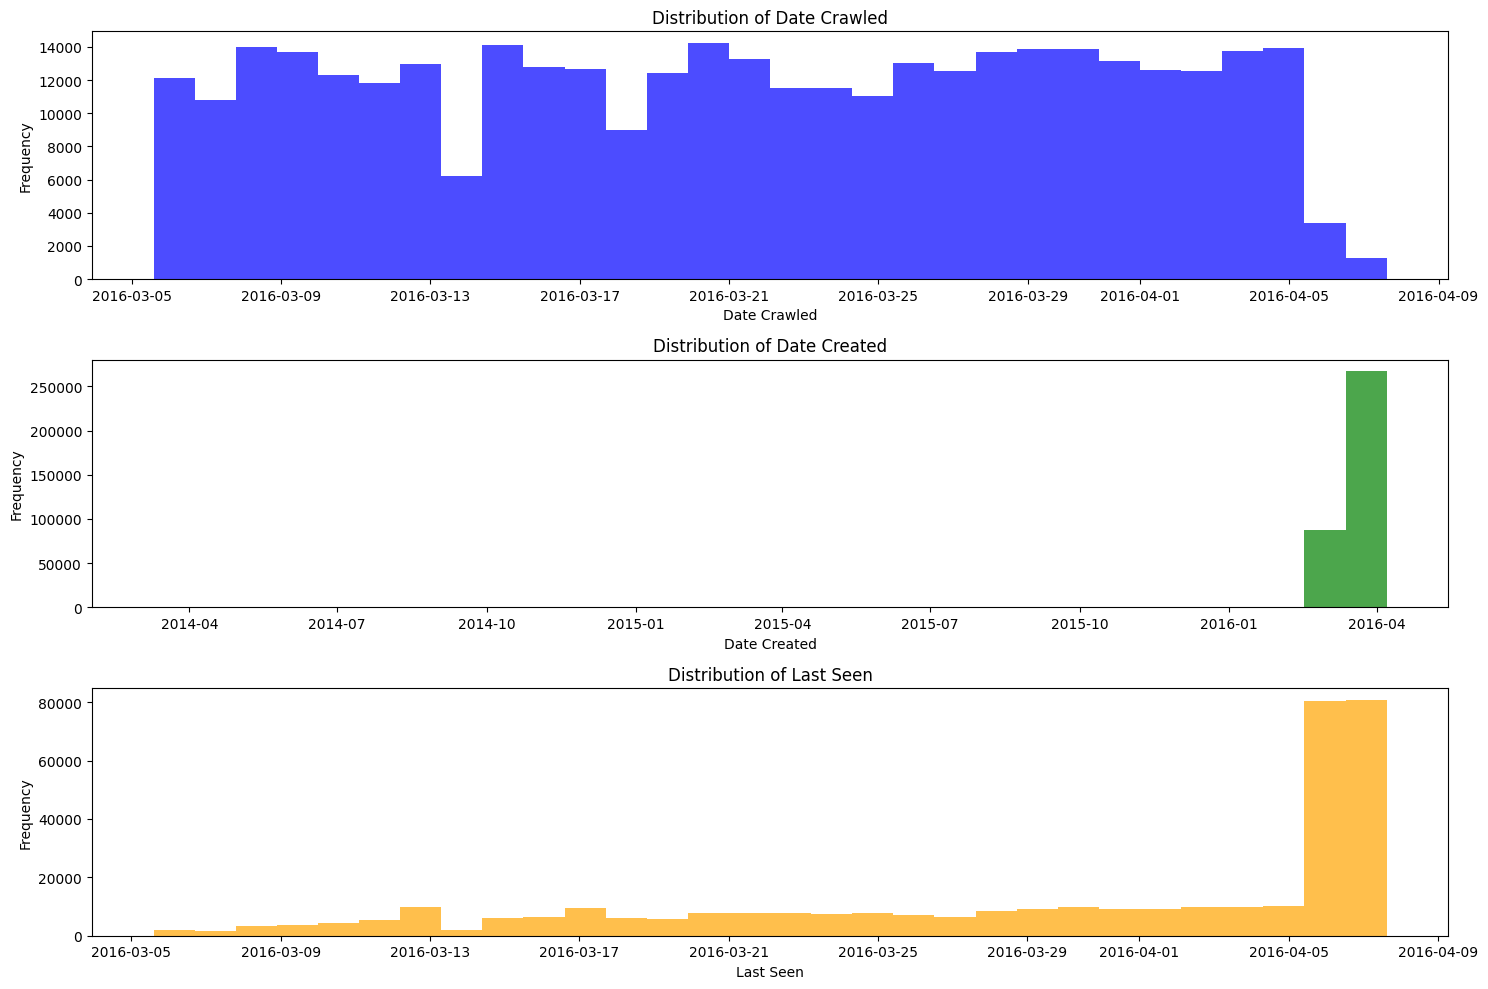

In [32]:
# Настройка графиков
plt.figure(figsize=(15, 10))

# Гистограмма для 'date_crawled'
plt.subplot(3, 1, 1)
plt.hist(autos['date_crawled'], bins=30, alpha=0.7, color='blue')
plt.title('Distribution of Date Crawled')
plt.xlabel('Date Crawled')
plt.ylabel('Frequency')

# Гистограмма для 'date_created'
plt.subplot(3, 1, 2)
plt.hist(autos['date_created'], bins=30, alpha=0.7, color='green')
plt.title('Distribution of Date Created')
plt.xlabel('Date Created')
plt.ylabel('Frequency')

# Гистограмма для 'last_seen'
plt.subplot(3, 1, 3)
plt.hist(autos['last_seen'], bins=30, alpha=0.7, color='orange')
plt.title('Distribution of Last Seen')
plt.xlabel('Last Seen')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

- `date_crawled`: График показывает, что данные равномерно распределены в пределах рассматриваемого временного интервала: конец марта и начало апреля 2016 года.
- `date_created`: График демонстрирует значительный рост количества записей в марте-апреля 2016 года. Почти все записи созданы в этот период. Вероятно, пользователи продающие автомобили не имели ранее созданных аккаунтов и регистрировались заново.
- `last_seen`: График показывает, что большинство записей имеют дату последнего просмотра в начале апреля 2016 года (конец периода, за который выгружены данные). Это значит, что большая часть пользователей проявляют активность и регулярно заходят на сайт, чтобы посмотреть информацию о своих объявленияъ.

**'price'**

In [33]:
autos['price'].describe()

count    354365.000000
mean       4416.679830
std        4514.176349
min           0.000000
25%        1050.000000
50%        2700.000000
75%        6400.000000
max       20000.000000
Name: price, dtype: float64

In [34]:
wiskers(autos, 'price')

[(0, 14400)]

Распределение данных в колонке price выглядит адекватно, однако есть машины с ценой 0.

In [35]:
print(f'Доля записей с 0 ценой: {round(len(autos.query("price == 0"))/len(autos)*100, 2)}%')

Доля записей с 0 ценой: 3.04%


Удалим эти данные, т.к. машины как правило не продаются бесплатно.

In [36]:
autos = autos.query('price != 0')

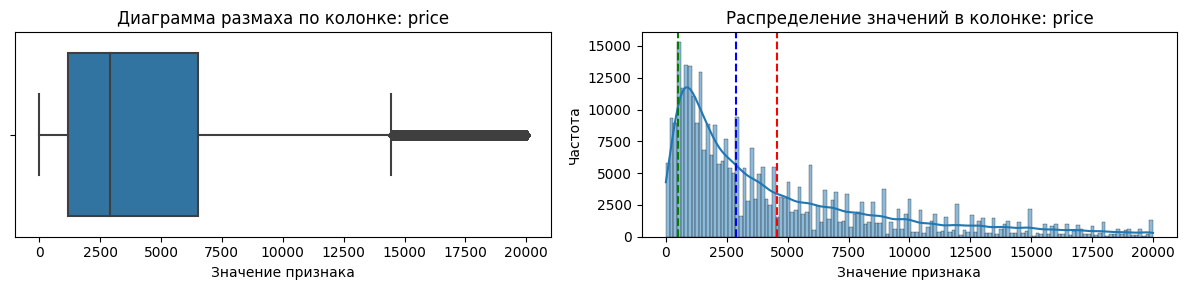

In [37]:
plot_box_hist_chart(autos['price'])

Машины с высокими ценами не являются выбросами. Оставим их как есть.

**'registration_year'**

In [38]:
autos['registration_year'].describe()

count    343593.00000
mean       2004.08983
std          78.41368
min        1000.00000
25%        1999.00000
50%        2003.00000
75%        2008.00000
max        9999.00000
Name: registration_year, dtype: float64

In [39]:
wiskers(autos, 'registration_year')

[(1986, 2019)]

In [40]:
sorted(autos['registration_year'].unique())

[1000,
 1001,
 1039,
 1111,
 1234,
 1255,
 1300,
 1400,
 1500,
 1600,
 1602,
 1800,
 1910,
 1923,
 1925,
 1927,
 1928,
 1929,
 1930,
 1931,
 1932,
 1933,
 1934,
 1935,
 1936,
 1937,
 1938,
 1940,
 1941,
 1942,
 1943,
 1944,
 1945,
 1946,
 1947,
 1948,
 1949,
 1950,
 1951,
 1952,
 1953,
 1954,
 1955,
 1956,
 1957,
 1958,
 1959,
 1960,
 1961,
 1962,
 1963,
 1964,
 1965,
 1966,
 1967,
 1968,
 1969,
 1970,
 1971,
 1972,
 1973,
 1974,
 1975,
 1976,
 1977,
 1978,
 1979,
 1980,
 1981,
 1982,
 1983,
 1984,
 1985,
 1986,
 1987,
 1988,
 1989,
 1990,
 1991,
 1992,
 1993,
 1994,
 1995,
 1996,
 1997,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2066,
 2200,
 2222,
 2290,
 2500,
 2800,
 2900,
 3000,
 3200,
 3700,
 3800,
 4000,
 4100,
 4500,
 4800,
 5000,
 5300,
 5555,
 5600,
 5900,
 5911,
 6000,
 6500,
 7000,
 7100,
 7800,
 8000,
 8200,
 8500,
 8888,
 9000,
 9450,
 9999]

Данные о машинах с годом выпуска раньше 1910 года и позже 2016 (дата выгрузки из базы) представляют собой явные аномалии или выбросы. Удалим их из выборки.

In [41]:
print(f'Доля записей с аномальным годом регистрации:\
    {round(len(autos.query("(registration_year < 1910) | (registration_year > 2019)")) / len(autos) * 100, 2)}%')


Доля записей с аномальным годом регистрации:    0.04%


In [42]:
# удалим аномалии
autos = autos.query('(registration_year >= 1910) & (registration_year <= 2016)')

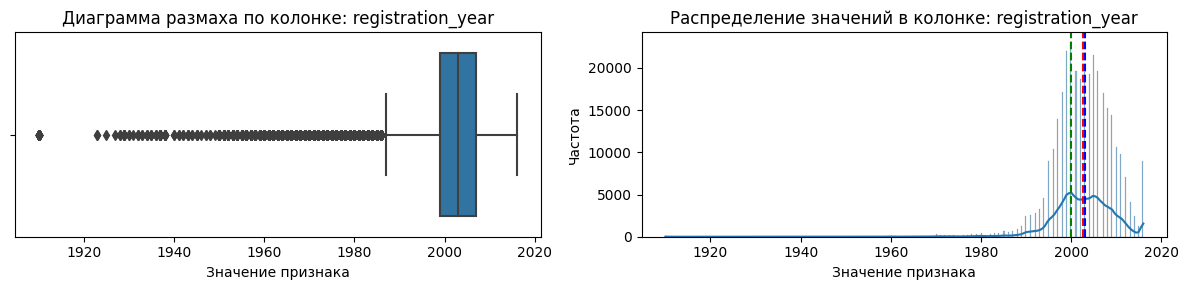

In [43]:
plot_box_hist_chart(autos['registration_year'])

**'power'**

In [44]:
autos['power'].describe()

count    329761.000000
mean        111.901641
std         184.850193
min           0.000000
25%          71.000000
50%         105.000000
75%         143.000000
max       20000.000000
Name: power, dtype: float64

In [45]:
wiskers(autos, 'power')

[(0, 251)]

Машин с мощностью 20000 не бывает - это явные аномалии, то же самое касается машин с мощностью около 0.

Удалим машины, которые имеют мощность >= 2000 л.с. и мощность <= 10 л.с.

In [46]:
autos = autos.query('(power <= 2000) & (power >= 10)')

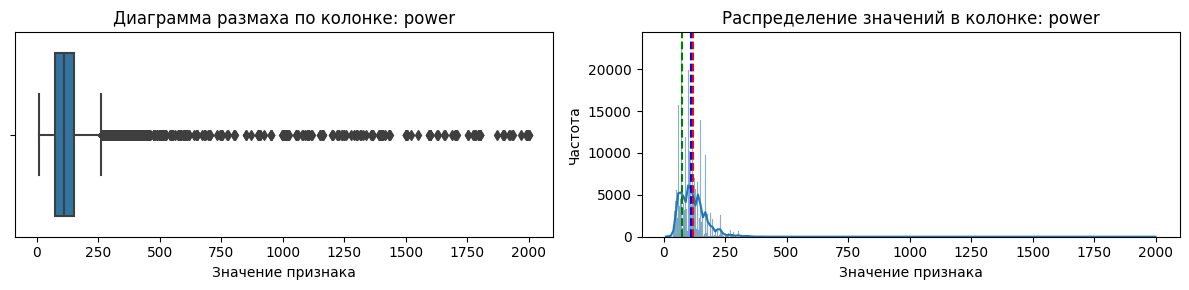

In [47]:
plot_box_hist_chart(autos['power'])

**'kilometer'**

In [48]:
autos['kilometer'].describe()

count    296585.000000
mean     128312.389366
std       36747.953449
min        5000.000000
25%      125000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: kilometer, dtype: float64

In [49]:
wiskers(autos, 'kilometer')

[(90000, 150000)]

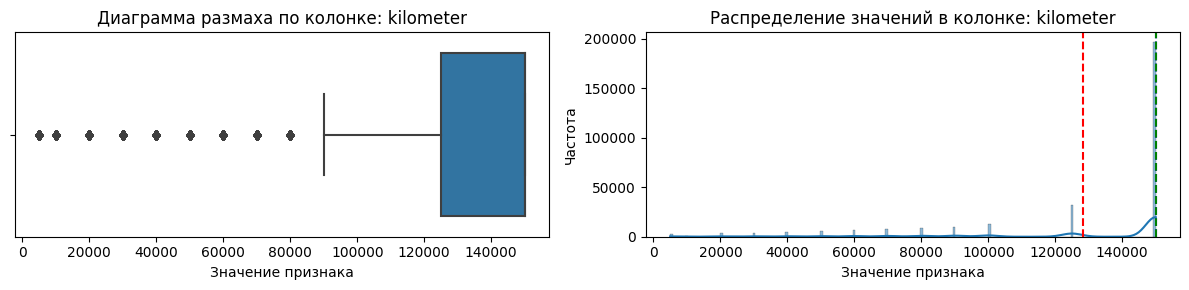

In [50]:
plot_box_hist_chart(autos['kilometer'])

В выгрузку по какой-то причине не попали авто с пробегом >= 150 тыс. км. Возможно на сайте есть ограничения на максимальный километраж и пользователь не може В целом данные о пробеге выглядят адекватно.

**'registration_month'**

In [51]:
autos['registration_month'].describe()

count    296585.000000
mean          5.992754
std           3.584247
min           0.000000
25%           3.000000
50%           6.000000
75%           9.000000
max          12.000000
Name: registration_month, dtype: float64

В выборку почему-то попали значения за 13 месяцев. Посмотрим на статистику количества автомобилей по месяцам:

In [52]:
len(autos['registration_month'].unique())

13

In [53]:
# посмотрим статистику продаж по месяцам
autos.groupby('registration_month')['price'].count()

registration_month
0     17996
1     20222
2     18894
3     30467
4     25796
5     25668
6     27609
7     23877
8     19751
9     20993
10    22990
11    21076
12    21246
Name: price, dtype: int64

In [54]:
# посмотрим корреляцию месяца с ценой автомобиля
autos['price'].corr(autos['registration_month'])

0.06921654396066468

Данные о продажах по месяцам распределены достаточно равномерно. Сложно понять, какой месяц был заполнен ошибочно. Возможно 0 ставился в тех записях, где месяц не был указан вовсе.

Корреляция месяца регистрации с ценой автомобиля достаточно низкая, и на практике месяц регистрации как правило не влияет на цену.

Этот признак можно удалить из выборки, т.к. он практически не влияет на цену.

In [55]:
autos = autos.drop('registration_month', axis=1)

**'vehicle_type', 'gearbox', 'fuel_type', 'brand', 'repaired'**

In [56]:
# Определяем колонки для перебора
grouping_columns = [
    'vehicle_type', 
    'gearbox', 
    'fuel_type',
    'brand', 
    'repaired'
]

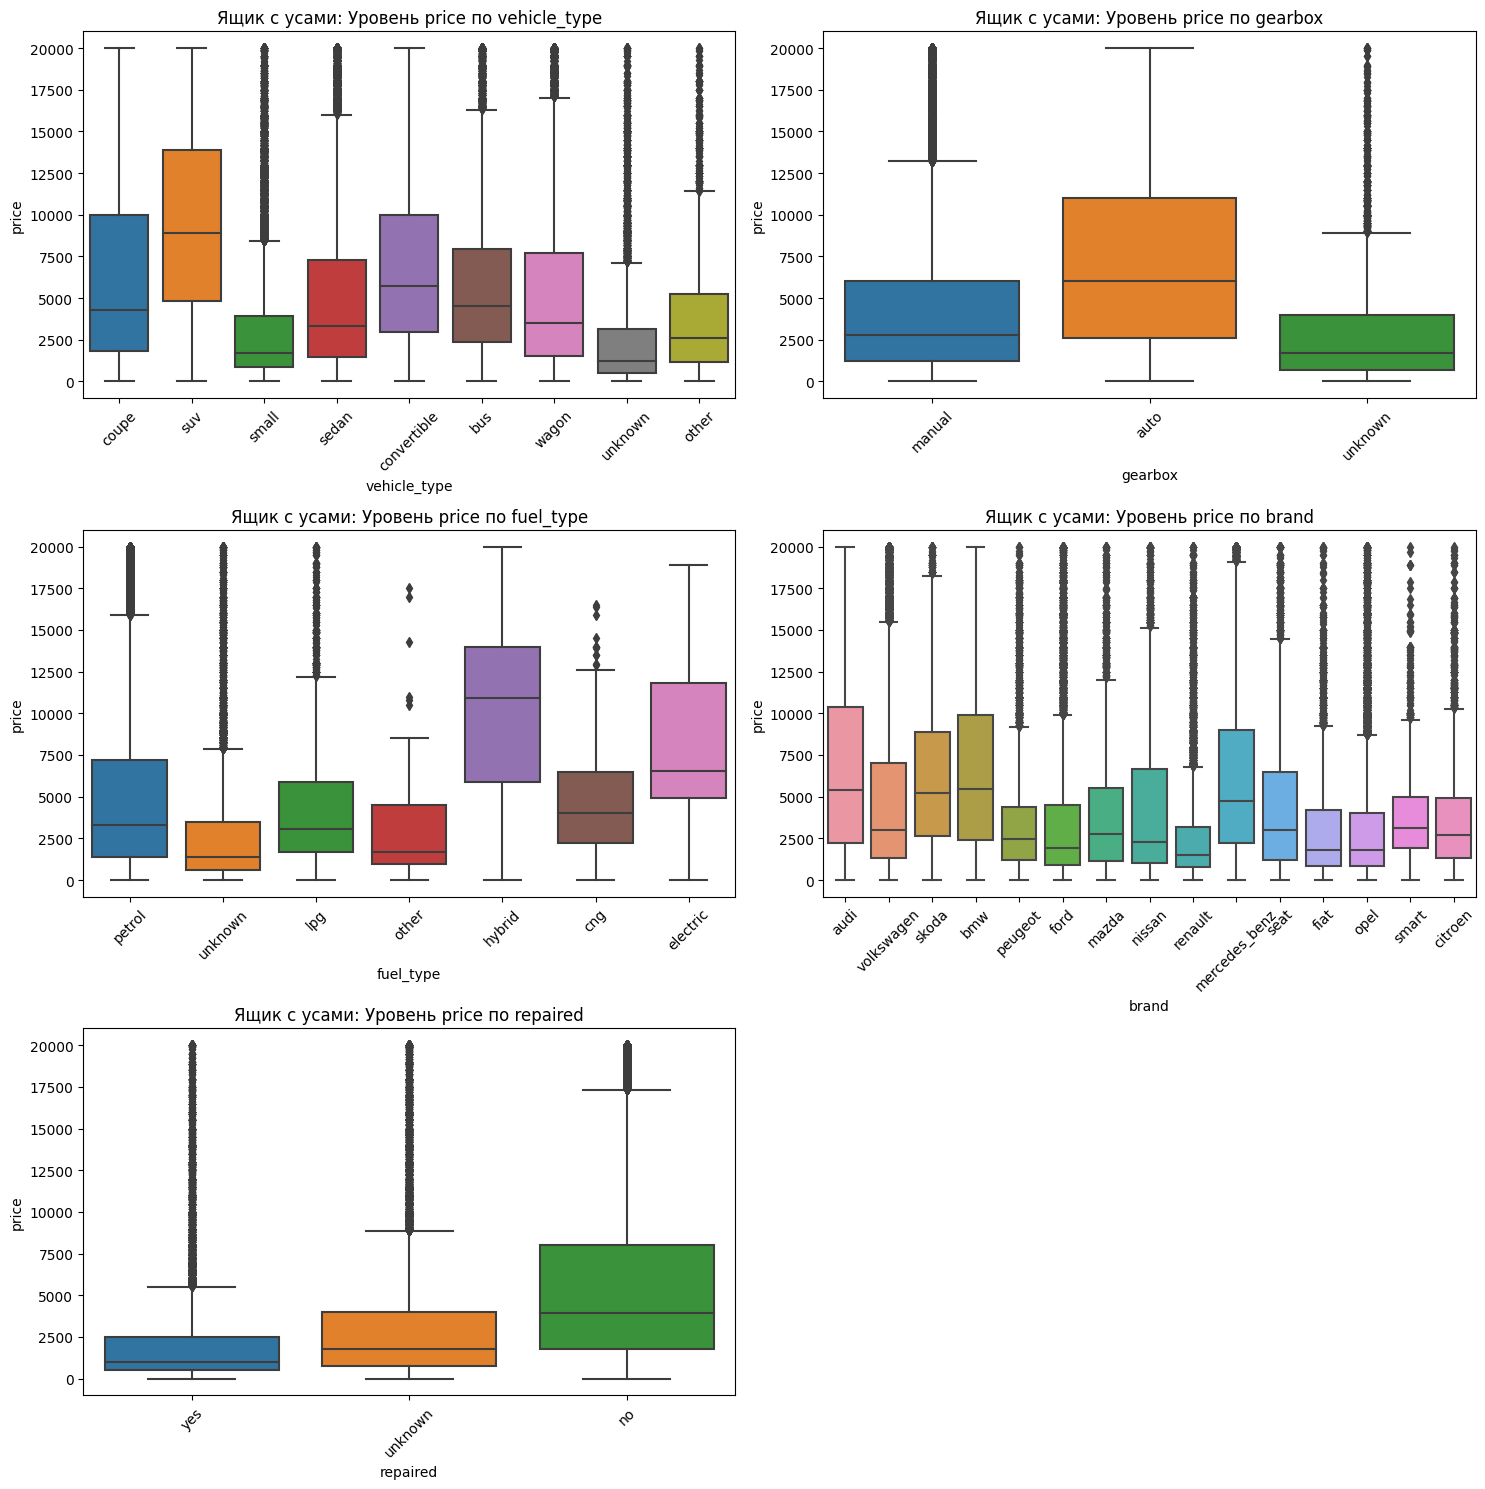

In [57]:
# Ограничим количество категорий 15 наиболее часто встречающимися значениями, чтобы они помещались на графики
plot_box_features_target(autos, grouping_columns, "price", top_n=15)

- `vehicle_type`: В среднем догоже всего стоят машины типа suv. Заметно также, что тип unknown (прежняя замена пропусков) и other (др. типы авто) похожи друг на друга. Можно объединить эти типы в один заменой unknown на other.
- `gearbox`: Авто с автоматической коробкой в среднем стоят дороже, чем с ручной. Тип коробки unknown по распределению цены авто очень близок к manual. В принципе, можно было бы произвести такую замену, но для достоверности оставим пропуски в отдельной категории.
- `fuel_type`: Дороже всего стоят гибриды, электрокары и машины на газу (вероятно требовали установки доп. оборудования, заложенного в цену). Типы unknown и other практически дублируют друг друга, объединим их в одну категорию other.
- `brand`: На графике видны более дорогие премиальные бренды, а также более дешевые. В целом ничего необычного.
- `repaired`: машины с пропусками в колонке repaired стоят в среднем практически также, как и машины побывавшие в ремонте. Но оставим пропуски в отдельной категории.

In [58]:
autos[['vehicle_type', 'fuel_type']] = autos[['vehicle_type', 'fuel_type']].replace('unknown', 'other')

In [59]:
autos['vehicle_type'].unique()

array(['coupe', 'suv', 'small', 'sedan', 'convertible', 'bus', 'wagon',
       'other'], dtype=object)

In [60]:
autos['fuel_type'].unique()

array(['petrol', 'other', 'lpg', 'hybrid', 'cng', 'electric'],
      dtype=object)

**'model'**

In [61]:
autos['model'].value_counts()

golf                  24736
other                 20460
3er                   17399
unknown               11073
polo                  10694
                      ...  
kalina                    5
samara                    5
serie_2                   5
serie_3                   3
range_rover_evoque        2
Name: model, Length: 249, dtype: int64

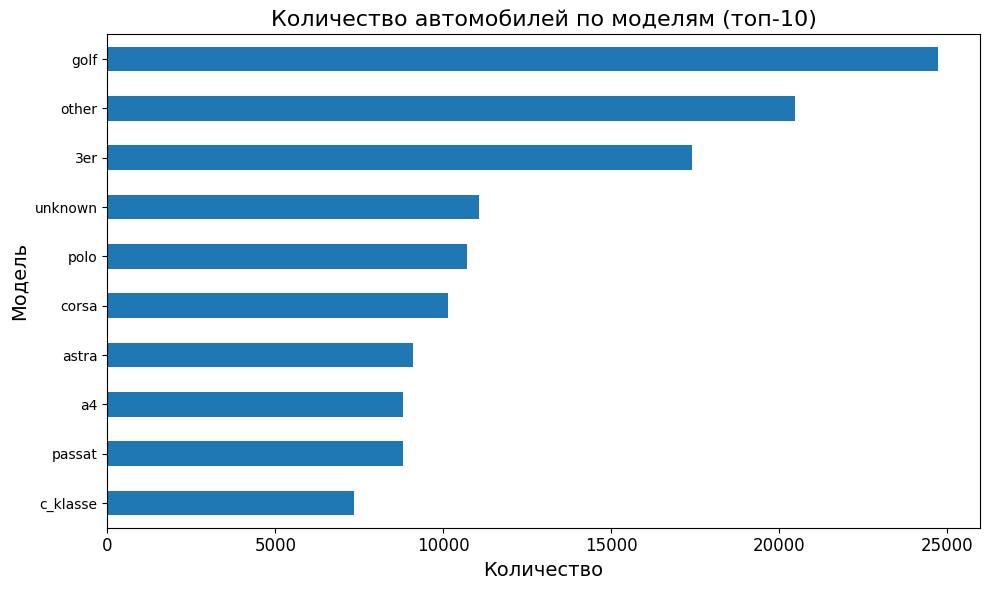

In [62]:
# Подсчёт количества уникальных моделей
model_counts = autos['model'].value_counts().head(10).sort_values(ascending=True)  # Топ-10 моделей, отсортированные по количеству

# Построение графика
plt.figure(figsize=(10, 6))
model_counts.plot(kind='barh')
plt.title('Количество автомобилей по моделям (топ-10)', fontsize=16)
plt.xlabel('Количество', fontsize=14)
plt.ylabel('Модель', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)
plt.tight_layout()  # Уплотняет график для лучшего отображения
plt.show()

Самая популярная модель - golf. Категории unknown и other объедими в одну. 

In [63]:
autos['model'] = autos['model'].replace('unknown', 'other')

In [64]:
sorted(autos['model'].unique())

['100',
 '145',
 '147',
 '156',
 '159',
 '1_reihe',
 '1er',
 '200',
 '2_reihe',
 '300c',
 '3_reihe',
 '3er',
 '4_reihe',
 '500',
 '5_reihe',
 '5er',
 '601',
 '6_reihe',
 '6er',
 '7er',
 '80',
 '850',
 '90',
 '900',
 '9000',
 '911',
 'a1',
 'a2',
 'a3',
 'a4',
 'a5',
 'a6',
 'a8',
 'a_klasse',
 'accord',
 'agila',
 'alhambra',
 'almera',
 'altea',
 'amarok',
 'antara',
 'arosa',
 'astra',
 'auris',
 'avensis',
 'aveo',
 'aygo',
 'b_klasse',
 'b_max',
 'beetle',
 'berlingo',
 'bora',
 'boxster',
 'bravo',
 'c1',
 'c2',
 'c3',
 'c4',
 'c5',
 'c_klasse',
 'c_max',
 'c_reihe',
 'caddy',
 'calibra',
 'captiva',
 'carisma',
 'carnival',
 'cayenne',
 'cc',
 'ceed',
 'charade',
 'cherokee',
 'citigo',
 'civic',
 'cl',
 'clio',
 'clk',
 'clubman',
 'colt',
 'combo',
 'cooper',
 'cordoba',
 'corolla',
 'corsa',
 'cr_reihe',
 'croma',
 'crossfire',
 'cuore',
 'cx_reihe',
 'defender',
 'delta',
 'discovery',
 'doblo',
 'ducato',
 'duster',
 'e_klasse',
 'elefantino',
 'eos',
 'escort',
 'espace',
 

**'postal_code'**

In [65]:
autos['postal_code'].value_counts()

10115    798
65428    505
66333    275
60311    261
52525    249
        ... 
17248      1
16837      1
30176      1
83256      1
94359      1
Name: postal_code, Length: 8116, dtype: int64

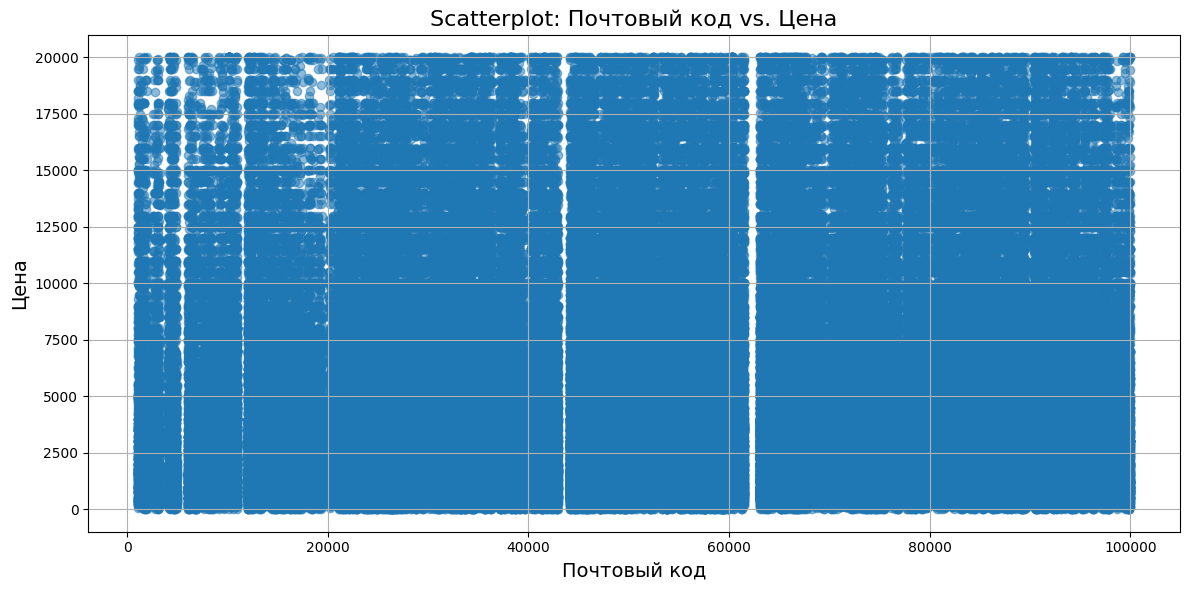

In [66]:
# Создание scatterplot
plt.figure(figsize=(12, 6))
plt.scatter(autos['postal_code'], autos['price'], alpha=0.5)
plt.title('Scatterplot: Почтовый код vs. Цена', fontsize=16)
plt.xlabel('Почтовый код', fontsize=14)
plt.ylabel('Цена', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)  # Добавление сетки для лучшей читабельности
plt.tight_layout()  # Уплотняет график для лучшего отображения
plt.show()

Каких-то зависимостей или аномалей в распределении цен авто по почтовому коду не видно.

### Корреляционный анализ данных

Признаки `date_crawled`, `date_created`, `last_seen` не имеют логической связи с ценой автомобиля. Удалим их из таблицы.

In [67]:
autos = autos.drop(['date_crawled', 'date_created', 'last_seen'], axis=1)

In [68]:
autos.head()

,price,vehicle_type,registration_year,gearbox,power,model,kilometer,fuel_type,brand,repaired,postal_code
1,18300,coupe,2011,manual,190,other,125000,petrol,audi,yes,66954
2,9800,suv,2004,auto,163,grand,125000,petrol,jeep,unknown,90480
3,1500,small,2001,manual,75,golf,150000,petrol,volkswagen,no,91074
4,3600,small,2008,manual,69,fabia,90000,petrol,skoda,no,60437
5,650,sedan,1995,manual,102,3er,150000,petrol,bmw,yes,33775


In [69]:
# Т.к. датафрейм слишком большой, построим корреляционную матрицу на выборке (5%)
autos_sampled = autos.sample(frac=0.05, random_state=RANDOM_STATE)

# Определим интервальные переменные
interval_columns = ['price','power'] 

F:\anaconda3\envs\practicum\lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable postal_code is large: 5138. Are you sure this is not an interval variable? Analysis for pairs of variables including postal_code can be slow.
  warnings.warn(


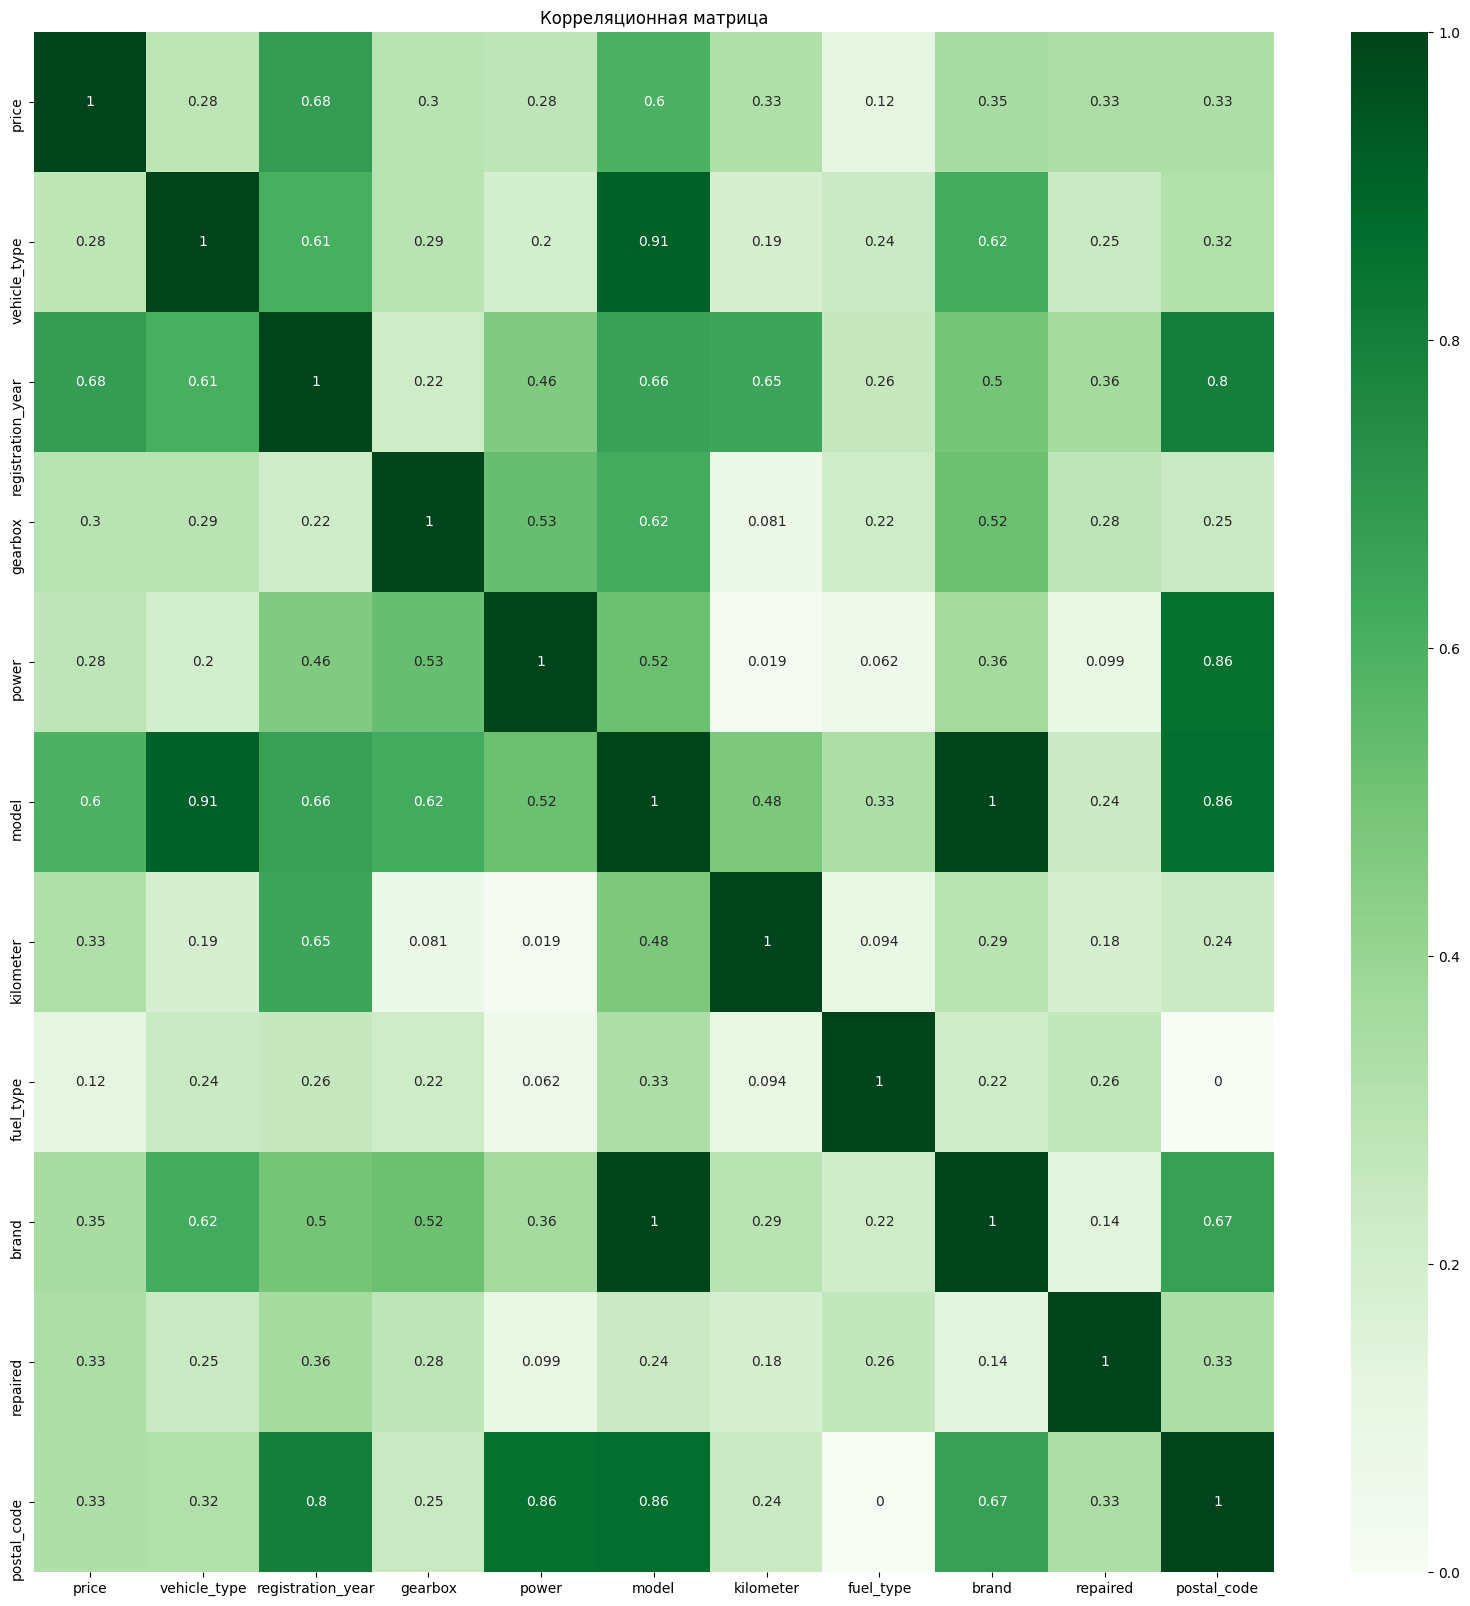

In [70]:
# Создадим матрицу корреляций
plt.figure(figsize=(20, 20))
sns.heatmap(autos_sampled 
            # колонки с датами выгрузки, регистрации пользователя и последнего посещения не будем учитывать, т.к. они не несут смысла в точки зрения определения стоимости авто
            # также не будем учитывать Postal code, т.к. это все таки не интервальная величина, но она содержит слишком много уникальных значений.
            # прямого влияния postal code на цену авто быть не должно
            .phik_matrix(interval_cols=interval_columns),
            annot=True,
            cmap='Greens')
plt.title("Корреляционная матрица")
plt.show()

Больше всего на цену авто влиет модель год регистрации (0.68) и модель авто (0.6). Все остальные параметры также оказывают небольшое влияние примерно в равной степени.

В таблице также заметна сильная автокорреляция:
- между моделью и брендом (коэф. 1)
- межд моделью и типом автомобиля (коэф. 0.91)

Чтобы линейные модели работали адекватно, сохраним отдельный датасет для линейных моделей без указанных выше признаков. Оставим только `model`, т.к. он больше всего влияет на целевую переменную.

In [71]:
autos_linear = autos.drop(['brand', 'vehicle_type'], axis=1)

Учитывая уменьшение числа независимых признаков, проверим и удалим полные дубликаты в получившихся выборках.

In [72]:
autos_linear.duplicated().sum()

21747

In [73]:
autos.duplicated().sum()

20523

In [74]:
autos_linear = autos_linear.drop_duplicates()
autos = autos.drop_duplicates()

In [75]:
autos.head()

,price,vehicle_type,registration_year,gearbox,power,model,kilometer,fuel_type,brand,repaired,postal_code
1,18300,coupe,2011,manual,190,other,125000,petrol,audi,yes,66954
2,9800,suv,2004,auto,163,grand,125000,petrol,jeep,unknown,90480
3,1500,small,2001,manual,75,golf,150000,petrol,volkswagen,no,91074
4,3600,small,2008,manual,69,fabia,90000,petrol,skoda,no,60437
5,650,sedan,1995,manual,102,3er,150000,petrol,bmw,yes,33775


In [76]:
autos_linear.head()

,price,registration_year,gearbox,power,model,kilometer,fuel_type,repaired,postal_code
1,18300,2011,manual,190,other,125000,petrol,yes,66954
2,9800,2004,auto,163,grand,125000,petrol,unknown,90480
3,1500,2001,manual,75,golf,150000,petrol,no,91074
4,3600,2008,manual,69,fabia,90000,petrol,no,60437
5,650,1995,manual,102,3er,150000,petrol,yes,33775


## Обучение моделей

### Описание признаков и выбор метрики

**Целевая переменная:** `price`

**Категориальные признаки (неранговые):**

- `gearbox`
- `model`
- `fuel_type`
- `repaired`
- `vehicle_type` (кроме линейной)
- `brand` (кроме линейной)

**Количественные признаки:**
- `registration_year`
- `power`
- `kilometer`
- `postal_code`

**Выбор метрики:**

- **RMSE (Root Mean Squared Error)**: По условиям задачи для оценки качества моделей применим метрику RMSE. RMSE измеряет среднеквадратичное отклонение предсказанных значений от фактических. Чем ниже значение RMSE, тем точнее модель в предсказании стоимости автомобиля.

### Подготовка данных

In [77]:
# Выделим целевую переменную и входящие признаки в разные переменные
y = autos['price']
X = autos.drop('price', axis=1)

print(y.shape, X.shape)

(276062,) (276062, 10)


In [78]:
# Выделим целевую переменную и входящие признаки в разные переменные (для линейной модели)
y_lin = autos_linear['price']
X_lin = autos_linear.drop('price', axis=1)

print(y_lin.shape, X_lin.shape)

(274838,) (274838, 8)


In [79]:
# Разделим данные на обучающий и тестовый набор
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE
)

# Проверим размеры выборок
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(207046, 10) (207046,) (69016, 10) (69016,)


In [80]:
# Разделим данные на обучающий и тестовый набор (для линейной модели)
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin,
    y_lin,
    test_size=0.25,
    random_state=RANDOM_STATE
)

# Проверим размеры выборок
print(X_train_lin.shape, y_train_lin.shape, X_test_lin.shape, y_test_lin.shape)

(206128, 8) (206128,) (68710, 8) (68710,)


#### Создание пайплайна

In [81]:
# Создадим списки с названиями признаков

# Списки признаков
cat_columns_linear = [
    'gearbox',
    'model',
    'fuel_type',
    'repaired'
]

cat_columns_tree = [
    'gearbox',
    'model',
    'fuel_type',
    'repaired',
    'vehicle_type',
    'brand'
]

num_columns = [
    'registration_year',
    'power',
    'kilometer',
    'postal_code'
]

In [82]:
# Пайплайн для OHE
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

In [83]:
# Пайплайн для OrdinalEncoder
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

In [84]:
# Пайплайн предобработки для линейной модели
data_preprocessor_linear = ColumnTransformer(
    transformers=[
        ('ohe', ohe_pipe, cat_columns_linear),
        ('num', StandardScaler(), num_columns)
    ],
    remainder='passthrough'
)

# Пайплайн предобработки для дерева решений и бустинга
data_preprocessor_tree = ColumnTransformer(
    transformers=[
        ('ord', ord_pipe, cat_columns_tree) # для деревьев и бустинга скейлинг не обязателен, вместо ohe используем ord
    ],
    remainder='passthrough'
)

In [85]:
# Итоговый пайплайн для линейной модели
linear_pipe = Pipeline([
    ('preprocessor', data_preprocessor_linear),
    ('models', LinearRegression())
])

# Итоговый пайплайн для дерева решений
tree_pipe = Pipeline([
    ('preprocessor', data_preprocessor_tree),
    ('models', DecisionTreeRegressor())
])

#### Поиск лучшей модели

Рассмотрим 4 базовые модели регрессии:
- LinearRegression
- DecisionTreeRegressor
- CatBoostRegressor
- LGBMRegressor

Для модели, которая быстрей и качественнее справится с обучением, подберем дополнительные гиперпараметры.  

In [86]:
# Создадим списки для хранения названия паратров модели, метрики, времени обучения и времени предсказания:

models = []
scores = []
time_fits = []
time_preds = []

**LinearRegression**

In [87]:
# Настраиваем сетку для перебора параметров
param_grid_linear = [
    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']        
    }
]

In [88]:
gs_lin, results_lin, score_lin, time_fit_lin, time_pred_lin = find_best_model(
    linear_pipe,
    param_grid_linear,
    X_train_lin,
    y_train_lin,
    cv=3,
    scoring='neg_root_mean_squared_error',
    search_type='grid'
)

Лучшая модель и её параметры:


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gearbox', 'model',
                                                   'fuel_type', 'repaired']),
                                                 ('num', StandardScaler(),
                                                  ['registration_year', 'power',
                                                   'kilometer',
                                                   'postal_code'])])),
                ('models', LinearRegression())])

Лучшая метрика на кросс-валидации для лучшей модели: 2869.2897507721214

Время поиска лучшей модели: 30.1663 секунд
Время обучения лучшей модели: 4.5209 секунд
Время предсказания лучшей модели на обучающей выборке: 0.5327 секунд


In [89]:
# Добавляем значения в соответствующие списки
models.append('LinearRegression')  # Добавляем название модели
scores.append(score_lin)
time_fits.append(time_fit_lin)
time_preds.append(time_pred_lin)

**DecisionTreeRegressor**

In [90]:
param_grid_tree = [
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(1, 31),
        'models__min_samples_split': range(2, 21),
        'models__min_samples_leaf': range(1, 21)
    }
]

In [91]:
gs_tree, results_tree, score_tree, time_fit_tree, time_pred_tree = find_best_model(
    tree_pipe,
    param_grid_tree,
    X_train,
    y_train,
    n_iter=30, # Ограничимся 30 итерациями 
    cv=3,
    scoring='neg_root_mean_squared_error',
    search_type='random' # используем RandomizedSearchCV, т.к. параметров перебора больше
)

Лучшая модель и её параметры:


F:\anaconda3\envs\practicum\lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['gearbox', 'model',
                                                   'fuel_type', 'repaired',
                                                   'vehicle_type',
                                                   'brand'])])),
                ('models',
                 DecisionTreeRegressor(max_depth=17, min_samples_leaf=13,
                                       min_samples_split=15,
                                       random_state=42))])

Лучшая метрика на кросс-валидации для лучшей модели: 1876.4611726957185

Время поиска лучшей модели: 29.5895 секунд
Время обучения лучшей модели: 1.4912 секунд
Время предсказания лучшей модели на обучающей выборке: 0.4079 секунд


In [92]:
# Добавляем значения в соответствующие списки
models.append('DecisionTreeRegressor')  # Добавляем название модели
scores.append(score_tree)
time_fits.append(time_fit_tree)
time_preds.append(time_pred_tree)

**CatBoostRegressor**

In [93]:
param_grid_catboost = [
    {
        'models': [CatBoostRegressor(random_state=RANDOM_STATE, verbose=0)] # Используем внешнюю кодировку ord
    }
]

In [94]:
gs_cat, results_cat, score_cat, time_fit_cat, time_pred_cat = find_best_model(
    tree_pipe,
    param_grid_catboost,
    X_train,
    y_train,
    cv=3,
    scoring='neg_root_mean_squared_error',
    search_type='grid'
)

Лучшая модель и её параметры:


F:\anaconda3\envs\practicum\lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['gearbox', 'model',
                                                   'fuel_type', 'repaired',
                                                   'vehicle_type',
                                                   'brand'])])),
                ('models',
                 <catboost.core.CatBoostRegressor object at 0x000001C5583A9760>)])

Лучшая метрика на кросс-валидации для лучшей модели: 1629.2502458621711

Время поиска лучшей модели: 52.5290 секунд
Время обучения лучшей модели: 16.0306 секунд
Время предсказания лучшей модели на обучающей выборке: 0.8624 секунд


In [95]:
# Добавляем значения в соответствующие списки
models.append('CatBoostRegressor')  # Добавляем название модели
scores.append(score_cat)
time_fits.append(time_fit_cat)
time_preds.append(time_pred_cat)

**LGBMRegressor**

In [96]:
param_grid_lgbm = [
    {
        'models': [LGBMRegressor(random_state=RANDOM_STATE)] # Используем внешнюю кодировку ord
    }
]

In [97]:
gs_lgbm, results_lgbm, score_lgbm, time_fit_lgbm, time_pred_lgbm = find_best_model(
    tree_pipe,
    param_grid_lgbm,
    X_train,
    y_train,
    cv=3,
    scoring='neg_root_mean_squared_error',
    search_type='grid'
)

F:\anaconda3\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006120 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 905
[LightGBM] [Info] Number of data points in the train set: 207046, number of used features: 10
[LightGBM] [Info] Start training from score 4821.692822


F:\anaconda3\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007086 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 905
[LightGBM] [Info] Number of data points in the train set: 207046, number of used features: 10
[LightGBM] [Info] Start training from score 4821.692822


F:\anaconda3\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Лучшая модель и её параметры:


F:\anaconda3\envs\practicum\lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['gearbox', 'model',
                                                   'fuel_type', 'repaired',
                                                   'vehicle_type',
                                                   'brand'])])),
                ('models', LGBMRegressor(random_state=42))])

Лучшая метрика на кросс-валидации для лучшей модели: 1700.4685095781376

Время поиска лучшей модели: 4.1590 секунд
Время обучения лучшей модели: 1.1898 секунд
Время предсказания лучшей модели на обучающей выборке: 0.7121 секунд


In [98]:
# Добавляем значения в соответствующие списки
models.append('LGBMRegressor')  # Добавляем название модели
scores.append(score_lgbm)
time_fits.append(time_fit_lgbm)
time_preds.append(time_pred_lgbm)

Достаточно быстрая модель по сравнению с catboost.

Поскольку скорость обучения важна для заказчика, то попробуем подобрать некоторые гиперпараметры, чтобы улучшить качество предсказаний.

In [99]:
param_grid_lgbm_hyp = [
    {
        'models': [LGBMRegressor(random_state=RANDOM_STATE)],
        'models__learning_rate': [0.1, 0.5],  # Шаг обучения, 0.1 по умолчанию
        'models__n_estimators': [100, 300]  # Количество деревьев, 100 по умолчанию
    }
]

In [100]:
gs_lgbm_hyp, results_lgbm_hyp, score_lgbm_hyp, time_fit_lgbm_hyp, time_pred_lgbm_hyp = find_best_model(
    tree_pipe,
    param_grid_lgbm_hyp,
    X_train,
    y_train,
    cv=3,
    scoring='neg_root_mean_squared_error',
    search_type='grid'
)

F:\anaconda3\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 905
[LightGBM] [Info] Number of data points in the train set: 207046, number of used features: 10
[LightGBM] [Info] Start training from score 4821.692822


F:\anaconda3\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 905
[LightGBM] [Info] Number of data points in the train set: 207046, number of used features: 10
[LightGBM] [Info] Start training from score 4821.692822


F:\anaconda3\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Лучшая модель и её параметры:


F:\anaconda3\envs\practicum\lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['gearbox', 'model',
                                                   'fuel_type', 'repaired',
                                                   'vehicle_type',
                                                   'brand'])])),
                ('models', LGBMRegressor(n_estimators=300, random_state=42))])

Лучшая метрика на кросс-валидации для лучшей модели: 1632.97010651886

Время поиска лучшей модели: 14.6340 секунд
Время обучения лучшей модели: 1.9717 секунд
Время предсказания лучшей модели на обучающей выборке: 1.4252 секунд


In [101]:
# Добавляем значения в соответствующие списки
models.append('LGBMRegressor + hyper')  # Добавляем название модели
scores.append(score_lgbm_hyp)
time_fits.append(time_fit_lgbm_hyp)
time_preds.append(time_pred_lgbm_hyp)

**DummyRegressor**

In [102]:
param_grid_dummy = [
    {
        'models': [DummyRegressor()],
        'models__strategy': ['mean', 'median'],
    },
    {
        'models': [DummyRegressor()],
        'models__strategy': ['quantile'],
        'models__quantile': [0.1, 0.25, 0.5, 0.75, 0.9],
    }
]

In [103]:
gs_dummy, results_dummy, score_dummy, time_fit_dummy, time_pred_dummy = find_best_model(
    tree_pipe,
    param_grid_dummy,
    X_train,
    y_train,
    cv=3,
    scoring='neg_root_mean_squared_error',
    search_type='grid'
)

Лучшая модель и её параметры:


F:\anaconda3\envs\practicum\lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['gearbox', 'model',
                                                   'fuel_type', 'repaired',
                                                   'vehicle_type',
                                                   'brand'])])),
                ('models', DummyRegressor())])

Лучшая метрика на кросс-валидации для лучшей модели: 4604.330111167471

Время поиска лучшей модели: 5.0867 секунд
Время обучения лучшей модели: 0.5036 секунд
Время предсказания лучшей модели на обучающей выборке: 0.3012 секунд


In [104]:
# Добавляем значения в соответствующие списки
models.append('DummyRegressor')  # Добавляем название модели
scores.append(score_dummy)
time_fits.append(time_fit_dummy)
time_preds.append(time_pred_dummy)

## Анализ моделей

In [105]:
# Соберем все результаты в одну таблицу
df = pd.DataFrame({
    'Model': models,
    'Score': scores,
    'Time_Fit': time_fits,
    'Time_Pred': time_preds
})
df

,Model,Score,Time_Fit,Time_Pred
0,LinearRegression,2869.289751,4.520886,0.532743
1,DecisionTreeRegressor,1876.461173,1.491184,0.407911
2,CatBoostRegressor,1629.250246,16.030573,0.862401
3,LGBMRegressor,1700.468510,1.189751,0.712098
4,LGBMRegressor + hyper,1632.970107,1.971728,1.425188
5,DummyRegressor,4604.330111,0.503619,0.301206


In [106]:
# Функция для расчета общей оценки на основе присвоенных весов
def calculate_total_score(df, weights):
    # Инициализация скейлера
    scaler = MinMaxScaler()

    # Нормализация значений
    df[['Score_Normalized', 'Time_Fit_Normalized', 'Time_Pred_Normalized']] = scaler.fit_transform(df[['Score', 'Time_Fit', 'Time_Pred']].values)

    # Инвертирование нормализованных значений
    df['Score_Normalized'] = 1 - df['Score_Normalized']
    df['Time_Fit_Normalized'] = 1 - df['Time_Fit_Normalized']
    df['Time_Pred_Normalized'] = 1 - df['Time_Pred_Normalized']
    
    
    # Расчет общей оценки с использованием нормализованных значений
    df['Total_Score'] = (
        df['Score_Normalized'] * weights['score_weight'] +
        df['Time_Fit_Normalized'] * weights['time_fit_weight'] +
        df['Time_Pred_Normalized'] * weights['time_pred_weight']
    ) * 100
    
    # Округление Total_Score до 2 знаков после запятой
    df['Total_Score'] = df['Total_Score'].round(2)

    # Удаление лишних колонок с нормализованными значениями
    df = df.drop(columns=['Score_Normalized', 'Time_Fit_Normalized', 'Time_Pred_Normalized'])

    return df

In [107]:
# Установка весов (сумма весов должна быть равна 1)
weights = {
    'score_weight': 0.5,       # 50% веса
    'time_fit_weight': 0.25,    # 25% веса
    'time_pred_weight': 0.25     # 25% веса
}

# Применение функции для расчета итогового скоринга
df_with_scores = calculate_total_score(df, weights)

# Сортировка моделей по Total_Score (чем выше балл, тем лучше модель)
df_with_scores = df_with_scores.sort_values(by='Total_Score', ascending=False)
df_with_scores

,Model,Score,Time_Fit,Time_Pred,Total_Score
1,DecisionTreeRegressor,1876.461173,1.491184,0.407911,91.88
3,LGBMRegressor,1700.468510,1.189751,0.712098,88.56
4,LGBMRegressor + hyper,1632.970107,1.971728,1.425188,72.57
0,LinearRegression,2869.289751,4.520886,0.532743,67.54
2,CatBoostRegressor,1629.250246,16.030573,0.862401,62.52
5,DummyRegressor,4604.330111,0.503619,0.301206,50.00


**Сводная оценка**

Для сравнения моделей и принятия решения для выбора лучшей модели параметрам оценки качества моделей были присовены следующие веса:

- качество предсказания (50%);
- скорость предсказания (25%);
- время обучения (25%).

После чего полученные значения `Score`, `Time_Fit`, `Time_Pred` были нормализованы (от 0 до 1) и инвертированы (чтобы лучшая модель имела более высокий балл).

Далее был расчитан финальный скоринг (`Total_Score`) моделей как сумма произведений инвертированных и нормализованных значений соответствующих параметров на их удельный вес. Далее оценка была умноженная на 100, чтобы она показывает оценку по шкале от 0 до 100. Чем лучше модель себя показала относительно других моделей, тем выше у нее оценка.

**Выводы**

- Лучше всего показала себя модель **`DecisionTreeRegressor`**: Она быстрее всех обучается и делает прогноз. При это прогноз среднего качества.
- Хорошо показала себя модель **`LGBMRegressor`**: Ее качество оказалось выше, но обучение и прогноз требуют немного больше времени. При подборе гиперпараметров была найдена модель с большим числом итераций (n_estimators=300 по сравнению с n_estimators=100 по умолчанию), соответственно это позволило немного улучшить качество модели, но еще более заметно выросло время обучения и предсказания. Поэтому модель с подобранными гиперпараметрами получила более низкий балл.
- **`CatBoostRegressor`**: Модель с базовыми настройками показала самый лучший RMSE из всех других моделей и отличное время предсказания. Однако обучение модели занимает слишком много времени (самое долгое обучение). Возможно, если переобучение модели будет производиться редко и для заказчика намного важней качество и скорость предсказания, то эта модель может побороться за лучшее место в рейтинге.
- **`LinearRegression`**: У получившейся модели самая большая RMSE с отрывом, модель не смогла распознать более сложные зависимости в данных. При этом, по времени обучения и предсказания модель также показала себя не самым лучшим образом.
- **`DummyRegressor`**: быстрая, но совершенно неточная примитивная модель. Ошибка существенно выше чем в других моделях.

При изменении весов модели, рейтинг моделей может измениться в зависимости от того, какому параметру заказчик отдаст больший вес.

**Предсказания лучшей модели на тестовой выборке**

In [108]:
best_model = gs_tree.best_estimator_

In [109]:
# сделаем предсказания на тестовой выборки
start = time()
y_test_pred = best_model.predict(X_test)
end = time()

delta_time = end - start
print(f'Время предсказания на тестовой выборке: {round(delta_time,2)} секунд')

Время предсказания на тестовой выборке: 0.14 секунд


In [110]:
# Расчет RMSE
rmse = root_mean_squared_error(y_test, y_test_pred)
print("RMSE на тестовых данных:", rmse)

RMSE на тестовых данных: 1811.8275613457274


Отлично, значение RMSE и время предсказания на тестовой выборке близки к тем, что были получены на кросс-валидации. Модель работает стабильно и ее можно использовать.